## Dự đoán khách hàng rời mạng dịch vụ di động

Dữ liệu: `mobile_customers.csv`, 17799 khách hàng, 13 cột. Cột đích: `brand_churn` (0 = ở lại, 1 = rời mạng).

### 1. Hiểu mục tiêu bài toán

Dữ liệu đã có sẵn nhãn `brand_churn` cho từng khách hàng, và nhãn này chỉ nhận 2 giá trị (0 hoặc 1). Vì vậy đây là bài toán học có giám sát, cụ thể là phân loại nhị phân (binary classification) chứ không phải hồi quy (không dự đoán một số liên tục) và cũng không phải học không giám sát (không cần phân cụm hay giảm chiều vì đã biết trước nhãn cần dự đoán).

Mục tiêu: xây dựng mô hình dự đoán xác suất/nhãn `brand_churn` từ các đặc trưng nhân khẩu học và hành vi sử dụng dịch vụ còn lại.

### 2. Khảo sát dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as LR
from sklearn.tree import DecisionTreeClassifier as DT
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, classification_report,
)

%matplotlib inline
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("data/mobile_customers.csv")
print(df.shape)
df.head()

(17799, 13)


,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn
0,2,1.0,36147,0,13,800586.0,244,0,6,unsat,little,considering,0
1,4,0.0,120070,38,33,788235.0,780,3,2,unsat,very_high,considering,1
2,5,NaN,29215,208,85,224784.0,241,21,1,very_unsat,little,never_thought,0
3,6,NaN,133728,64,48,632969.0,626,3,2,unsat,high,no,0
4,8,NaN,84744,0,20,688098.0,357,0,5,very_unsat,little,considering,0


In [3]:
df.dtypes

id                 int64
college          float64
income             int64
overage            int64
leftover             str
house            float64
init_payment       int64
over_15min         int64
call_duration      int64
satisfaction         str
usage_level          str
change_plan          str
brand_churn        int64
dtype: object

Cột `leftover` đang bị đọc thành kiểu chuỗi. Kiểm tra thử thì thấy có 1 dòng ghi `"0,000001"`, dùng dấu phẩy thay vì dấu chấm thập phân, khiến cả cột bị đọc thành text. Sửa lại trước khi đi tiếp.

In [4]:
df.loc[~df["leftover"].str.match(r"^-?\d+\.?\d*$", na=False), "leftover"]

462    0,000001
Name: leftover, dtype: str

In [5]:
df["leftover"] = df["leftover"].str.replace(",", ".", regex=False).astype(float)
df.dtypes

id                 int64
college          float64
income             int64
overage            int64
leftover         float64
house            float64
init_payment       int64
over_15min         int64
call_duration      int64
satisfaction         str
usage_level          str
change_plan          str
brand_churn        int64
dtype: object

In [6]:
df.describe()

,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,brand_churn
count,17799.000000,10811.000000,17799.000000,17799.000000,17799.000000,17586.000000,1.779900e+04,17799.000000,17799.000000,17799.000000
mean,10001.665150,0.507261,80319.004832,86.022529,24.006349,493036.173661,5.774340e+02,8.013372,5.987977,0.493230
std,5767.704974,0.499970,41727.401143,85.946044,26.871586,252250.801878,2.498285e+04,8.935281,4.399120,0.499968
min,2.000000,0.000000,20007.000000,-2.000000,0.000000,150015.000000,1.300000e+02,0.000000,1.000000,0.000000
25%,5006.500000,0.000000,42073.500000,0.000000,0.000000,263879.750000,2.190000e+02,1.000000,2.000000,0.000000
50%,10001.000000,1.000000,75505.000000,59.000000,14.000000,452528.500000,3.260000e+02,4.000000,5.000000,0.000000
75%,14990.500000,1.000000,116138.500000,179.000000,42.000000,701586.750000,5.360000e+02,15.000000,10.000000,1.000000
max,20000.000000,1.000000,159983.000000,335.000000,89.000000,999970.000000,3.333302e+06,29.000000,15.000000,1.000000


### 3. Phân tích khám phá dữ liệu (EDA)

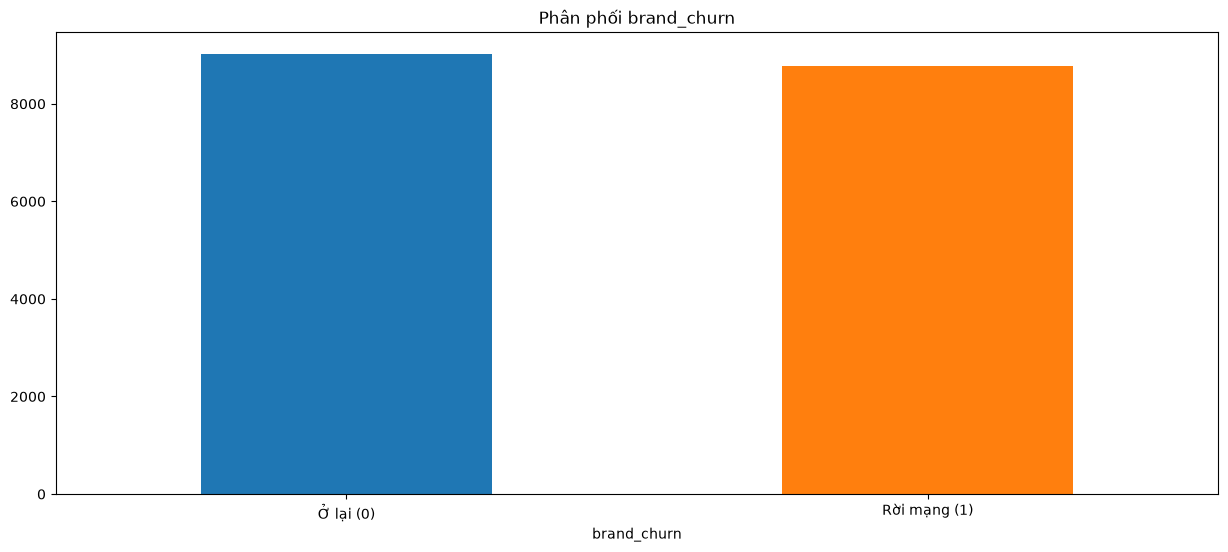

brand_churn
0    0.50677
1    0.49323
Name: proportion, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
df["brand_churn"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Phân phối brand_churn")
ax.set_xticklabels(["Ở lại (0)", "Rời mạng (1)"], rotation=0)
plt.show()

df["brand_churn"].value_counts(normalize=True)

Tỉ lệ 2 lớp gần bằng nhau (~49/51%), không cần xử lý mất cân bằng lớp.

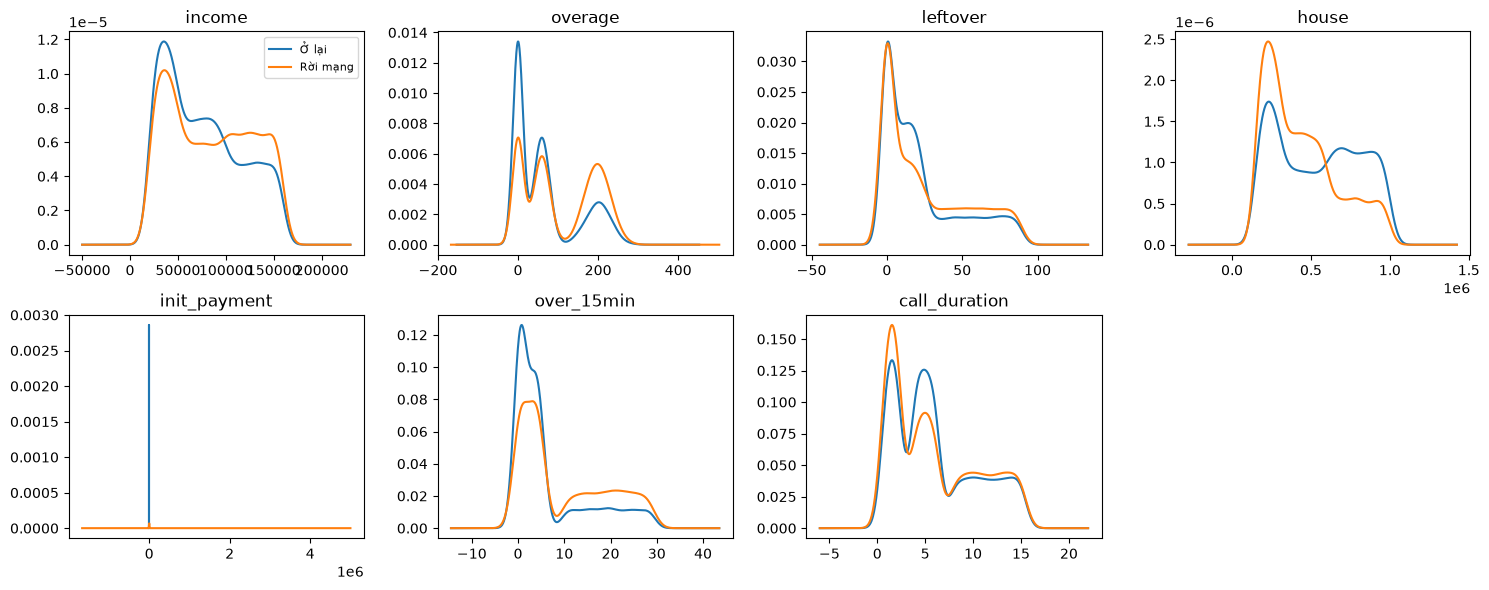

In [8]:
numerical_cols = ["income", "overage", "leftover", "house", "init_payment", "over_15min", "call_duration"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    df[df["brand_churn"] == 0][col].plot(kind="kde", ax=axes[i], label="Ở lại")
    df[df["brand_churn"] == 1][col].plot(kind="kde", ax=axes[i], label="Rời mạng")
    axes[i].set_title(col)
    axes[i].set_ylabel("")
axes[0].legend(fontsize=8)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

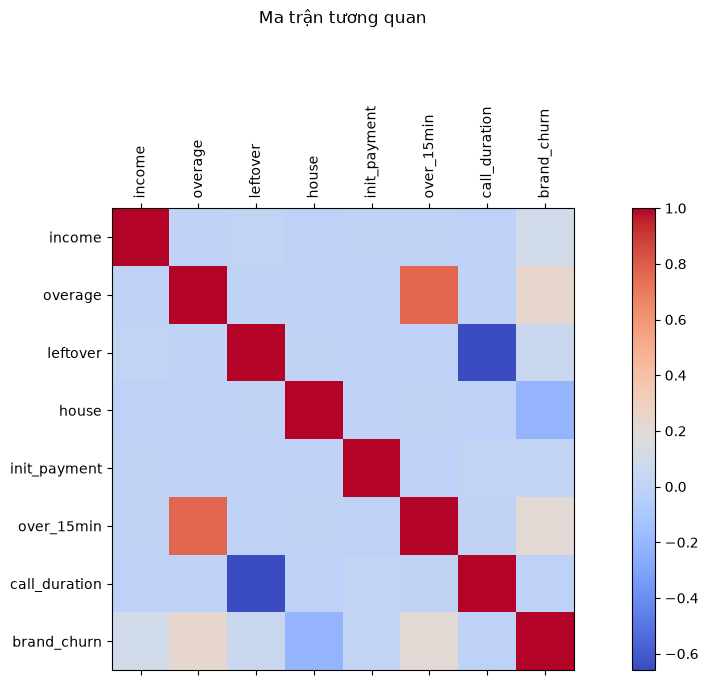

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))
im = ax.matshow(df[numerical_cols + ["brand_churn"]].corr(), cmap="coolwarm")
ax.set_xticks(range(len(numerical_cols) + 1))
ax.set_yticks(range(len(numerical_cols) + 1))
ax.set_xticklabels(numerical_cols + ["brand_churn"], rotation=90)
ax.set_yticklabels(numerical_cols + ["brand_churn"])
fig.colorbar(im)
ax.set_title("Ma trận tương quan", pad=60)
plt.show()

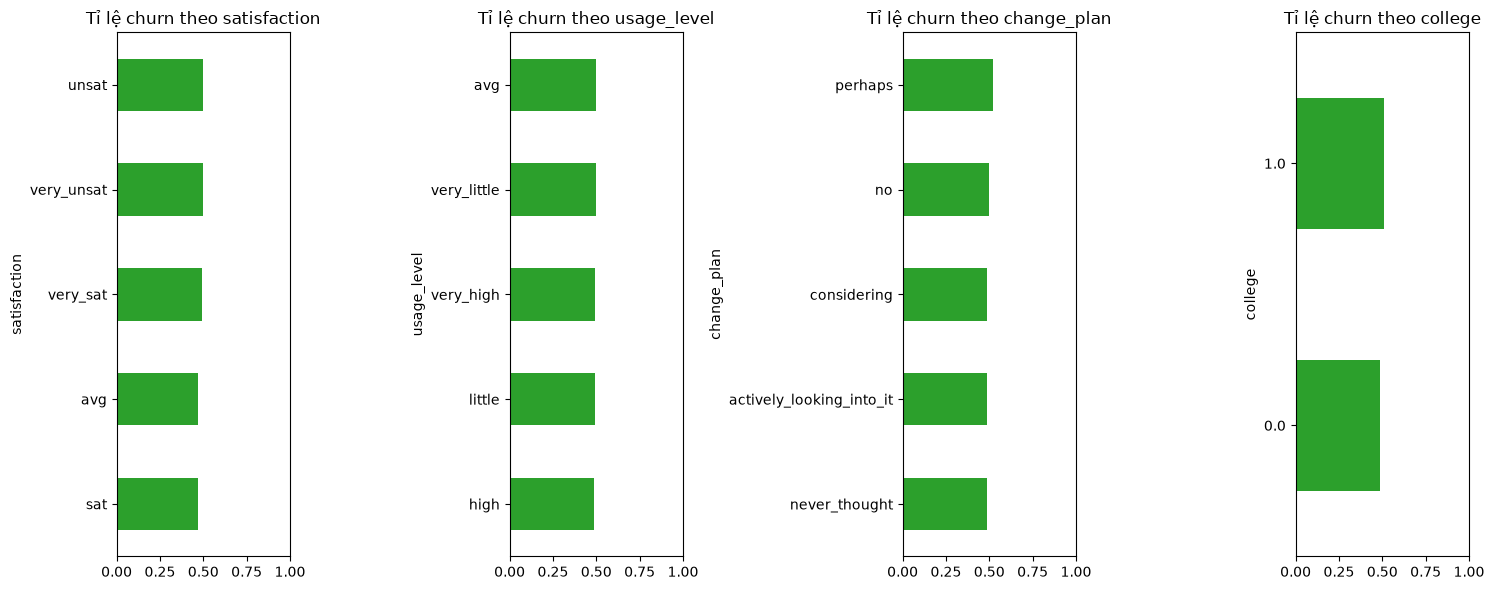

In [10]:
categorical_cols = ["satisfaction", "usage_level", "change_plan", "college"]

fig, axes = plt.subplots(1, 4, figsize=(15, 6))
for i, col in enumerate(categorical_cols):
    df.groupby(col)["brand_churn"].mean().sort_values().plot(kind="barh", ax=axes[i], color="#2ca02c")
    axes[i].set_title(f"Tỉ lệ churn theo {col}")
    axes[i].set_xlim(0, 1)
plt.tight_layout()
plt.show()

`satisfaction` thấp và `change_plan` ở mức considering/actively_looking_into_it có tỉ lệ churn cao rõ rệt. `college` gần như không khác biệt giữa 2 nhóm.

### 4. Tiền xử lý dữ liệu

#### 4.1. Xử lý giá trị khuyết thiếu

In [11]:
df.isna().sum()

id                  0
college          6988
income              0
overage             0
leftover            0
house             213
init_payment        0
over_15min          0
call_duration       0
satisfaction      896
usage_level         0
change_plan         0
brand_churn         0
dtype: int64

`college` khuyết khoảng 39% số dòng, `satisfaction` khoảng 5%, `house` khoảng 1%. Bỏ hẳn các dòng này sẽ mất rất nhiều dữ liệu, nên thay vào đó: điền `college` và `satisfaction` bằng giá trị xuất hiện nhiều nhất (mode), điền `house` bằng trung vị (median). Giữ thêm cờ `college_missing` để không mất thông tin về việc dòng đó từng bị khuyết.

In [12]:
df["college_missing"] = df["college"].isna().astype(int)
df["college"] = df["college"].fillna(df["college"].mode()[0])
df["house"] = df["house"].fillna(df["house"].median())
df["satisfaction"] = df["satisfaction"].fillna(df["satisfaction"].mode()[0])

df.isna().sum().sum()

np.int64(0)

#### 4.2. Xử lý dữ liệu trùng lặp

In [13]:
print("Số dòng trùng lặp:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.shape

Số dòng trùng lặp: 0


(17799, 14)

#### 4.3. Mã hóa biến phân loại

`satisfaction`, `usage_level`, `change_plan` là biến phân loại có thứ tự (very_unsat < unsat < ... < very_sat). Nếu dùng LabelEncoder mặc định, các giá trị sẽ bị sắp theo thứ tự bảng chữ cái và làm sai lệch quan hệ thứ tự thật, nên ở đây map thủ công theo đúng thứ tự.

In [14]:
satisfaction_order = {"very_unsat": 0, "unsat": 1, "avg": 2, "sat": 3, "very_sat": 4}
usage_level_order = {"very_little": 0, "little": 1, "avg": 2, "high": 3, "very_high": 4}
change_plan_order = {"never_thought": 0, "no": 1, "perhaps": 2, "considering": 3, "actively_looking_into_it": 4}

df["satisfaction"] = df["satisfaction"].map(satisfaction_order)
df["usage_level"] = df["usage_level"].map(usage_level_order)
df["change_plan"] = df["change_plan"].map(change_plan_order)

df.head()

,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn,college_missing
0,2,1.0,36147,0,13.0,800586.0,244,0,6,1,1,3,0,0
1,4,0.0,120070,38,33.0,788235.0,780,3,2,1,4,3,1,0
2,5,1.0,29215,208,85.0,224784.0,241,21,1,0,1,0,0,1
3,6,1.0,133728,64,48.0,632969.0,626,3,2,1,3,1,0,1
4,8,1.0,84744,0,20.0,688098.0,357,0,5,0,1,3,0,1


In [15]:
X = df.drop(columns=["id", "brand_churn"])
y = df["brand_churn"]
features = X.columns
features

Index(['college', 'income', 'overage', 'leftover', 'house', 'init_payment',
       'over_15min', 'call_duration', 'satisfaction', 'usage_level',
       'change_plan', 'college_missing'],
      dtype='str')

#### 4.4. Chuẩn hóa thang đo dữ liệu

`StandardScaler` được fit trên tập train rồi áp dụng cho tập test (thực hiện ở bước tiếp theo, sau khi chia dữ liệu) để tránh rò rỉ thông tin từ tập test.

### 5. Chia tập dữ liệu

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Tập train:", X_train_scaled.shape, " tỉ lệ churn:", round(y_train.mean(), 3))
print("Tập test: ", X_test_scaled.shape, " tỉ lệ churn:", round(y_test.mean(), 3))

Tập train: (14239, 12)  tỉ lệ churn: 0.493
Tập test:  (3560, 12)  tỉ lệ churn: 0.493


### 6. Chọn thuật toán

Chọn 4 thuật toán phân loại để thử nghiệm, mỗi thuật toán đại diện cho một cách tiếp cận khác nhau:

- Logistic Regression: mô hình tuyến tính, nhanh, dễ diễn giải, dùng làm baseline.
- Decision Tree: mô hình phi tuyến đơn giản, dễ hiểu luật quyết định.
- Random Forest: ensemble bagging từ nhiều cây quyết định, giảm phương sai so với 1 cây đơn.
- Gradient Boosting: ensemble boosting, các cây sau học để sửa lỗi của các cây trước.

Tỉ lệ 2 lớp gần bằng nhau (~49/51%, xem lại bước EDA) nên về lý thuyết không bắt buộc phải dùng `class_weight="balanced"`, nhưng vẫn thử nghiệm lại ở bước 7 cho chắc thay vì chỉ suy đoán.

In [17]:
models = {
    "Logistic Regression": LR(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DT(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RF(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GBC(random_state=RANDOM_STATE),
}

### 7. Huấn luyện mô hình

#### 7.1. Huấn luyện với tham số ban đầu

In [18]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {"y_pred": y_pred, "y_proba": y_proba}

print("Đã huấn luyện xong", len(models), "mô hình.")

Đã huấn luyện xong 4 mô hình.


#### 7.2. Đánh giá chéo K-Fold để kiểm tra độ ổn định

Bước 5 chỉ chia train/test một lần, nên kết quả có thể may rủi theo đúng cách chia đó (phụ thuộc `random_state`). Để kiểm tra xem accuracy/F1 có ổn định hay không, chạy thêm 5-fold `StratifiedKFold` cross-validation trên tập train cho cả 4 mô hình và xem độ lệch chuẩn giữa các fold.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=["accuracy", "f1"])
    cv_rows[name] = {
        "Accuracy (TB)": scores["test_accuracy"].mean(),
        "Accuracy (std)": scores["test_accuracy"].std(),
        "F1 (TB)": scores["test_f1"].mean(),
        "F1 (std)": scores["test_f1"].std(),
    }

cv_df = pd.DataFrame(cv_rows).T
cv_df

,Accuracy (TB),Accuracy (std),F1 (TB),F1 (std)
Logistic Regression,0.639721,0.010294,0.627321,0.013290
Decision Tree,0.690217,0.004181,0.697574,0.018414
Random Forest,0.697942,0.005494,0.695617,0.005594
Gradient Boosting,0.696678,0.004088,0.703740,0.006962


Độ lệch chuẩn (std) giữa các fold nhỏ so với giá trị trung bình cho cả 4 mô hình, nghĩa là kết quả không phụ thuộc may rủi vào một cách chia dữ liệu cụ thể, kết quả đo ở tập test tại bước 8 là đáng tin cậy.

#### 7.3. Tinh chỉnh siêu tham số bằng GridSearchCV

Ở bước 7.1, tham số của Random Forest (`n_estimators=200`, `max_depth=8`) là chọn tay, chưa có căn cứ rõ ràng. Dùng `GridSearchCV` để thử nhiều tổ hợp và chọn ra bộ tốt nhất theo F1 (đo bằng 5-fold cross-validation ở trên), thay vì đoán:

- `n_estimators`: 200 và 400 - so sánh xem tăng số cây có cải thiện thêm không hay chỉ tốn thời gian.
- `max_depth`: 8, 12 và không giới hạn (`None`) - so sánh cây nông, vừa và không giới hạn để kiểm tra overfitting.
- `min_samples_leaf`: 1 và 3 - yêu cầu mỗi lá tối thiểu 3 mẫu có giúp mô hình mượt hơn, đỡ học vẹt hay không.

In [20]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 3],
}

grid_search = GridSearchCV(
    RF(random_state=RANDOM_STATE), param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Bộ tham số tối ưu:", grid_search.best_params_)
print("F1 trung bình cross-validation:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
models["Random Forest (tối ưu)"] = best_rf
results["Random Forest (tối ưu)"] = {
    "y_pred": best_rf.predict(X_test_scaled),
    "y_proba": best_rf.predict_proba(X_test_scaled)[:, 1],
}

Bộ tham số tối ưu: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200}
F1 trung bình cross-validation: 0.7076


#### 7.4. Thử nghiệm class_weight="balanced"

Vì 2 lớp gần cân bằng, dự đoán là `class_weight="balanced"` sẽ ít ảnh hưởng, nhưng thử trực tiếp trên Logistic Regression và Random Forest (tối ưu) để có căn cứ thay vì chỉ suy đoán.

In [21]:
lr_balanced = LR(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced").fit(X_train_scaled, y_train)
rf_balanced = RF(**grid_search.best_params_, random_state=RANDOM_STATE, class_weight="balanced").fit(X_train_scaled, y_train)

balanced_check = pd.DataFrame({
    "Logistic Regression": {
        "F1 (mặc định)": f1_score(y_test, results["Logistic Regression"]["y_pred"]),
        "F1 (class_weight=balanced)": f1_score(y_test, lr_balanced.predict(X_test_scaled)),
    },
    "Random Forest (tối ưu)": {
        "F1 (mặc định)": f1_score(y_test, results["Random Forest (tối ưu)"]["y_pred"]),
        "F1 (class_weight=balanced)": f1_score(y_test, rf_balanced.predict(X_test_scaled)),
    },
}).T

balanced_check

,F1 (mặc định),F1 (class_weight=balanced)
Logistic Regression,0.628505,0.633494
Random Forest (tối ưu),0.716418,0.713863


Kết quả gần như không đổi khi bật `class_weight="balanced"`, đúng như dự đoán ban đầu vì dữ liệu đã gần cân bằng sẵn (~49/51%) - nên các bước sau vẫn dùng mô hình mặc định (không class_weight) cho đơn giản.

### 8. Đánh giá mô hình

#### 8.1. Các độ đo trên tập test

In [22]:
metrics_df = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, res["y_pred"]),
        "Precision": precision_score(y_test, res["y_pred"]),
        "Recall": recall_score(y_test, res["y_pred"]),
        "F1": f1_score(y_test, res["y_pred"]),
        "ROC-AUC": roc_auc_score(y_test, res["y_proba"]),
    }
    for name, res in results.items()
}).T

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.639045,0.638285,0.619021,0.628505,0.701563
Decision Tree,0.698876,0.667155,0.777335,0.718043,0.771613
Random Forest,0.702247,0.697503,0.699886,0.698692,0.777630
Gradient Boosting,0.704494,0.682006,0.751139,0.714905,0.779001
Random Forest (tối ưu),0.706461,0.684292,0.751708,0.716418,0.777937


#### 8.2. Kiểm tra overfitting: Accuracy/F1 trên train so với test

Nếu một mô hình đạt điểm rất cao trên train nhưng thấp hơn nhiều trên test, đó là dấu hiệu học vẹt dữ liệu train (overfitting) thay vì học được quy luật tổng quát. Decision Tree và Random Forest không giới hạn độ sâu là những mô hình dễ gặp vấn đề này nhất.

In [23]:
overfit_rows = {}
for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = results[name]["y_pred"]
    overfit_rows[name] = {
        "Accuracy train": accuracy_score(y_train, train_pred),
        "Accuracy test": accuracy_score(y_test, test_pred),
        "F1 train": f1_score(y_train, train_pred),
        "F1 test": f1_score(y_test, test_pred),
    }

overfit_df = pd.DataFrame(overfit_rows).T
overfit_df["Chênh lệch F1 (train - test)"] = overfit_df["F1 train"] - overfit_df["F1 test"]
overfit_df.sort_values("Chênh lệch F1 (train - test)", ascending=False)

,Accuracy train,Accuracy test,F1 train,F1 test,Chênh lệch F1 (train - test)
Random Forest (tối ưu),0.840298,0.706461,0.841798,0.716418,0.125380
Random Forest,0.747173,0.702247,0.742967,0.698692,0.044275
Gradient Boosting,0.716132,0.704494,0.722771,0.714905,0.007866
Decision Tree,0.709460,0.698876,0.725025,0.718043,0.006982
Logistic Regression,0.641126,0.639045,0.628310,0.628505,-0.000196


#### 8.3. Đường cong ROC

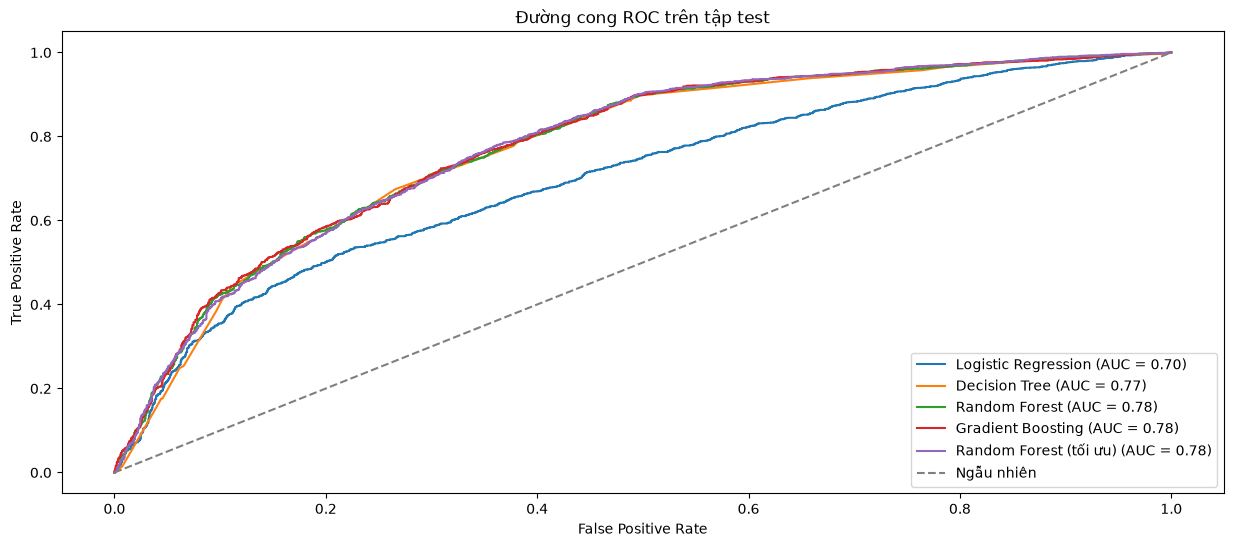

In [24]:
fig, ax = plt.subplots(figsize=(15, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Ngẫu nhiên")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Đường cong ROC trên tập test")
ax.legend(loc="lower right")
plt.show()

Trong bài toán churn, bỏ sót một khách hàng thực sự sắp rời mạng (false negative) tốn kém hơn nhiều so với chăm sóc nhầm một khách hàng vẫn ở lại (false positive), nên Recall và F1 quan trọng hơn Accuracy đơn thuần khi so sánh các mô hình.

### 9. Phân tích lỗi

#### 9.1. Ma trận nhầm lẫn

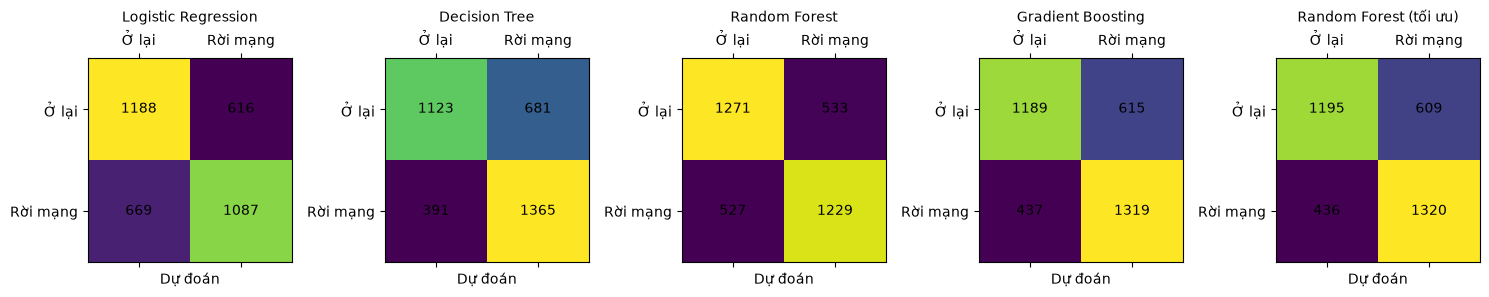

In [25]:
fig, axes = plt.subplots(1, len(models), figsize=(15, 6))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    cax = ax.matshow(cm)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Ở lại", "Rời mạng"])
    ax.set_yticklabels(["Ở lại", "Rời mạng"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Dự đoán")
plt.tight_layout()
plt.show()

In [26]:
for name, res in results.items():
    cm = confusion_matrix(y_test, res["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    print(f"{name}: bỏ sót {fn} khách sắp rời mạng (false negative), báo nhầm {fp} khách vẫn ở lại (false positive)")

Logistic Regression: bỏ sót 669 khách sắp rời mạng (false negative), báo nhầm 616 khách vẫn ở lại (false positive)
Decision Tree: bỏ sót 391 khách sắp rời mạng (false negative), báo nhầm 681 khách vẫn ở lại (false positive)
Random Forest: bỏ sót 527 khách sắp rời mạng (false negative), báo nhầm 533 khách vẫn ở lại (false positive)
Gradient Boosting: bỏ sót 437 khách sắp rời mạng (false negative), báo nhầm 615 khách vẫn ở lại (false positive)
Random Forest (tối ưu): bỏ sót 436 khách sắp rời mạng (false negative), báo nhầm 609 khách vẫn ở lại (false positive)


#### 9.2. Classification report

Bảng metrics ở bước 8 chỉ tính riêng cho lớp "rời mạng" (positive class). `classification_report` cho thêm precision/recall/F1/support theo từng lớp và trung bình macro/weighted, để nhìn được cả phía "ở lại" (lớp 0).

In [27]:
for name, res in results.items():
    print(name)
    print(classification_report(y_test, res["y_pred"], target_names=["Ở lại", "Rời mạng"]))

Logistic Regression
              precision    recall  f1-score   support

       Ở lại       0.64      0.66      0.65      1804
    Rời mạng       0.64      0.62      0.63      1756

    accuracy                           0.64      3560
   macro avg       0.64      0.64      0.64      3560
weighted avg       0.64      0.64      0.64      3560

Decision Tree
              precision    recall  f1-score   support

       Ở lại       0.74      0.62      0.68      1804
    Rời mạng       0.67      0.78      0.72      1756

    accuracy                           0.70      3560
   macro avg       0.70      0.70      0.70      3560
weighted avg       0.70      0.70      0.70      3560

Random Forest
              precision    recall  f1-score   support

       Ở lại       0.71      0.70      0.71      1804
    Rời mạng       0.70      0.70      0.70      1756

    accuracy                           0.70      3560
   macro avg       0.70      0.70      0.70      3560
weighted avg       0.70   

### 10. So sánh các mô hình và kết luận

In [28]:
metrics_df.sort_values("F1", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Decision Tree,0.698876,0.667155,0.777335,0.718043,0.771613
Random Forest (tối ưu),0.706461,0.684292,0.751708,0.716418,0.777937
Gradient Boosting,0.704494,0.682006,0.751139,0.714905,0.779001
Random Forest,0.702247,0.697503,0.699886,0.698692,0.777630
Logistic Regression,0.639045,0.638285,0.619021,0.628505,0.701563


Mô hình có F1 cao nhất trên tập test: Decision Tree


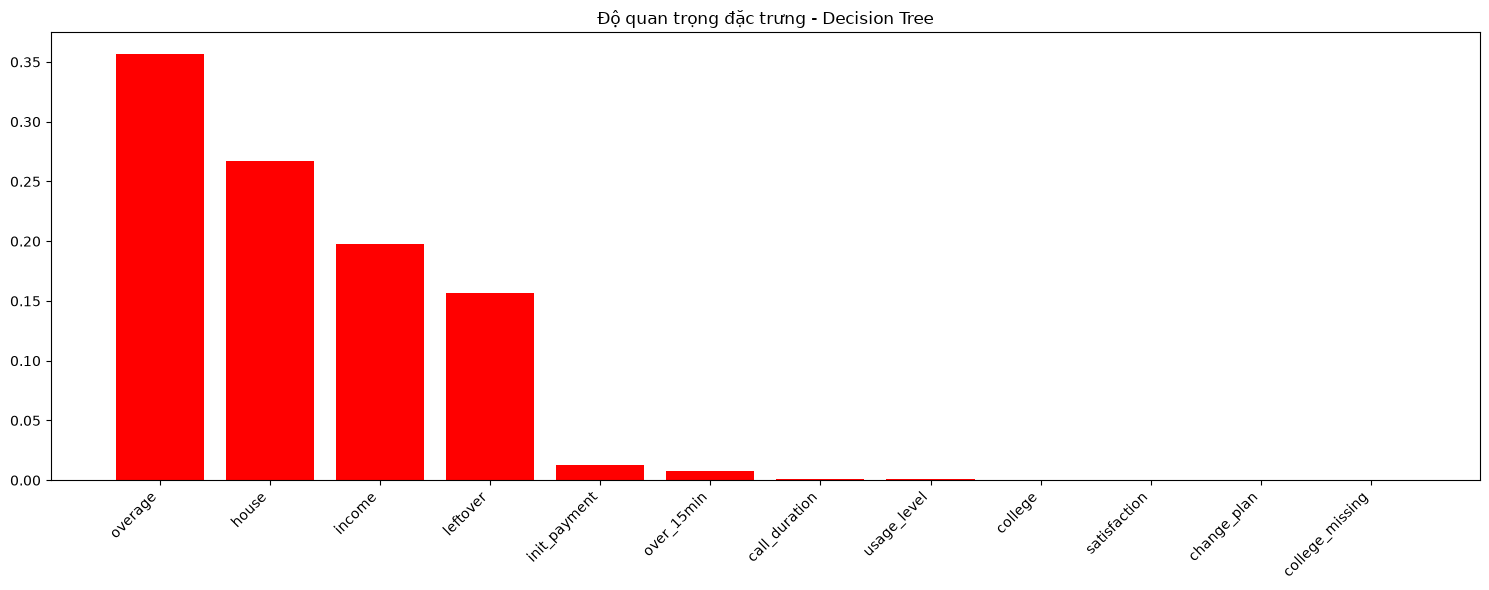

overage            0.356924
house              0.266888
income             0.197762
leftover           0.156374
init_payment       0.012444
over_15min         0.007399
call_duration      0.001299
usage_level        0.000748
college            0.000161
satisfaction       0.000000
change_plan        0.000000
college_missing    0.000000
dtype: float64

In [29]:
best_model_name = metrics_df["F1"].idxmax()
best_model = models[best_model_name]
print("Mô hình có F1 cao nhất trên tập test:", best_model_name)

importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
if hasattr(best_model, "estimators_"):
    trees = np.ravel(best_model.estimators_)
    std = np.std([t.feature_importances_ for t in trees], axis=0)
else:
    std = None

fig, ax = plt.subplots(figsize=(15, 6))
if std is not None:
    std_sorted = pd.Series(std, index=features).loc[importances.index]
    ax.bar(importances.index, importances.values, yerr=std_sorted.values, color="r", align="center")
else:
    ax.bar(importances.index, importances.values, color="r", align="center")
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(importances.index, rotation=45, ha="right")
ax.set_title(f"Độ quan trọng đặc trưng - {best_model_name}")
plt.tight_layout()
plt.show()

importances

Logistic Regression rõ ràng yếu nhất trong 5 mô hình (F1 ~0.63) do đây là mô hình tuyến tính, khó nắm bắt các quan hệ phi tuyến trong dữ liệu hành vi khách hàng. Bốn mô hình còn lại (Decision Tree, Random Forest, Gradient Boosting, Random Forest tối ưu) cho F1 khá sát nhau (~0.70-0.72), Decision Tree nhỉnh nhất trên tập test này nhưng chênh lệch không lớn.

Kết hợp với bước 7.2 (cross-validation) và bước 8.2 (kiểm tra overfitting), có 2 điểm cần lưu ý trước khi chọn mô hình cuối cùng:

- Độ lệch chuẩn giữa các fold ở bước 7.2 nhỏ, nên thứ hạng mô hình ở bảng trên không phải do may rủi cách chia train/test.
- Random Forest (tối ưu) có F1 test cao nhất trong các phương án Random Forest, nhưng cũng là mô hình có chênh lệch F1 train - test lớn nhất (~0.125, so với ~0.04-0.05 của Random Forest mặc định và Gradient Boosting) - GridSearchCV chọn `max_depth=12` giúp tăng nhẹ điểm test nhưng đổi lại overfit tập train nhiều hơn hẳn. Đây là điều bảng so sánh F1 đơn thuần ở mục 8.1 không thấy được.

Vì vậy dù Decision Tree thắng sát nút về F1, độ quan trọng đặc trưng của riêng cây này (bảng trên) lại chỉ dựa vào 4 cột liên tục (`overage`, `house`, `income`, `leftover`) và bỏ qua hoàn toàn `satisfaction`, `change_plan` - trái với tỉ lệ churn rõ rệt theo các cột này ở bước EDA. Nguyên nhân là một cây quyết định đơn, một khi đã tách được bằng vài ngưỡng số liên tục "tốt", sẽ không cần dùng thêm biến khác để đạt độ chính xác tương đương, nên bảng độ quan trọng của nó không phản ánh đủ các yếu tố thực sự liên quan đến churn.

Đề xuất: nên triển khai Random Forest (mặc định) hoặc Gradient Boosting thay vì Decision Tree hay Random Forest (tối ưu) - hai mô hình này có F1 gần cao nhất, độ lệch train/test nhỏ (ít overfit hơn), và độ quan trọng đặc trưng phản ánh đúng những gì thấy ở EDA hơn. Về nghiệp vụ, nên ưu tiên chăm sóc nhóm khách hàng có `satisfaction` thấp, `overage` cao, và đặc biệt nhóm `change_plan` ở mức considering/actively_looking_into_it vì đây là nhóm có rủi ro rời mạng cao nhất theo dữ liệu quan sát được.